<a href="https://colab.research.google.com/github/ohhceen/Analisis-Sentimen-Ulasan-Alfagift/blob/main/Alfagift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install Library
!pip install google-play-scraper Sastrawi gensim scikit-learn matplotlib seaborn wordcloud

# 2. Import Library
from google_play_scraper import Sort, reviews
import pandas as pd
import numpy as np

app_id = 'com.alfamart.alfagift'

result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=1000 # Mengambil 1000 data agar aman dari syarat minimal 500
)

df = pd.DataFrame(np.array(result), columns=['review'])
df = df.join(pd.DataFrame(df.pop('review').tolist()))

# Ambil kolom yang dibutuhkan saja
df = df[['content', 'score']]
print(f"Data berhasil diambil: {len(df)} baris")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.2 MB/s eta 0:00:00
Data berhasil diambil: 1000 baris


In [2]:
import pandas as pd

# 1. Ubah hasil scraping (list of dict) menjadi DataFrame Pandas
df = pd.DataFrame(result)

# 2. Simpan DataFrame ke file CSV
# index=False agar nomor baris tidak ikut tersimpan sebagai kolom baru
df.to_csv('ulasan_alfagift.csv', index=False)

print("File berhasil disimpan dengan nama: ulasan_alfagift.csv")

File berhasil disimpan dengan nama: ulasan_alfagift.csv


In [3]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Pelabelan Sederhana
# Skor 4-5 = Positif (1), Skor 1-2 = Negatif (0), Skor 3 dibuang (netral)
df = df[df['score'] != 3]
df['label'] = df['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi Sastrawi
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def nlp_preprocessing(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Hapus tanda baca & emoji
    text = re.sub(r'\d+', '', text)    # Hapus angka
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

# Proses preprocessing (mungkin butuh waktu 1-2 menit untuk 1000 data)
df['clean_text'] = df['content'].apply(nlp_preprocessing)
df.to_csv('data_siap_uji.csv', index=False)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Split Data
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42)

# --- METODE 1: TF-IDF ---
tfidf_vec = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

model_tfidf = SVC()
model_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = model_tfidf.predict(X_test_tfidf)

# --- METODE 2: Word2Vec (Word Embedding) ---
sentences = [s.split() for s in X_train]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

def get_mean_vector(text):
    words = text.split()
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_w2v = np.array([get_mean_vector(s) for s in X_train])
X_test_w2v = np.array([get_mean_vector(s) for s in X_test])

model_w2v = SVC()
model_w2v.fit(X_train_w2v, y_train)
pred_w2v = model_w2v.predict(X_test_w2v)

print(f"Akurasi TF-IDF: {accuracy_score(y_test, pred_tfidf)}")
print(f"Akurasi Word2Vec: {accuracy_score(y_test, pred_w2v)}")

Akurasi TF-IDF: 0.9731182795698925
Akurasi Word2Vec: 0.6021505376344086


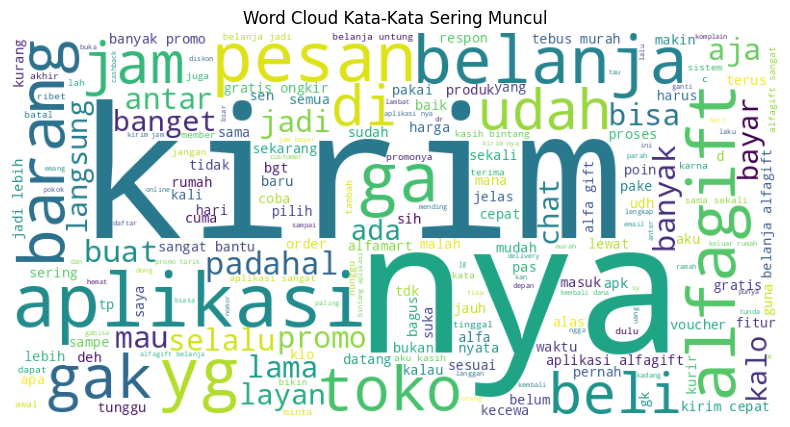

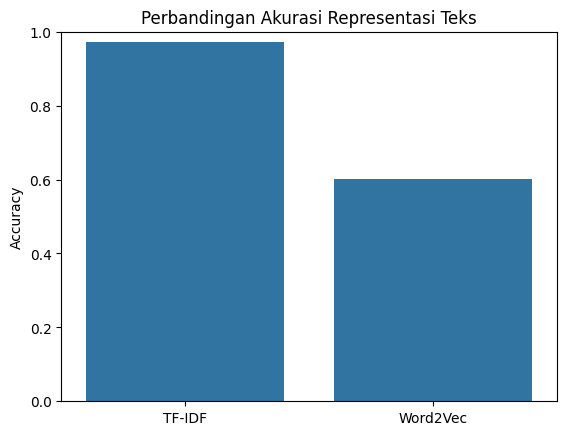

In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Visualisasi 1: Word Cloud
all_words = ' '.join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud Kata-Kata Sering Muncul')
plt.show()

# Visualisasi 2: Perbandingan Akurasi
methods = ['TF-IDF', 'Word2Vec']
scores = [accuracy_score(y_test, pred_tfidf), accuracy_score(y_test, pred_w2v)]
sns.barplot(x=methods, y=scores)
plt.ylim(0, 1)
plt.title('Perbandingan Akurasi Representasi Teks')
plt.ylabel('Accuracy')
plt.show()

In [6]:
def uji_ulasan_baru(teks_baru):
    # 1. Preprocessing ulasan baru
    clean_review = nlp_preprocessing(teks_baru)
    print(f"Ulasan Asli: {teks_baru}")
    print(f"Hasil Preprocessing: {clean_review}")
    print("-" * 30)

    # 2. Prediksi dengan TF-IDF
    tfidf_input = tfidf_vec.transform([clean_review])
    pred_tfidf_baru = model_tfidf.predict(tfidf_input)
    hasil_tfidf = "Positif" if pred_tfidf_baru[0] == 1 else "Negatif"

    # 3. Prediksi dengan Word2Vec
    w2v_input = np.array([get_mean_vector(clean_review)])
    pred_w2v_baru = model_w2v.predict(w2v_input)
    hasil_w2v = "Positif" if pred_w2v_baru[0] == 1 else "Negatif"

    print(f"Prediksi (TF-IDF)   : {hasil_tfidf}")
    print(f"Prediksi (Word2Vec) : {hasil_w2v}")

# --- EKSEKUSI UJI COBA ---
print("HASIL UJI COBA SENTIMEN\n")

# Contoh Ulasan Negatif
uji_ulasan_baru("Aplikasi ini sering error dan sangat lambat saat loading pembayaran!")
print("\n")

# Contoh Ulasan Positif
uji_ulasan_baru("Barangnya cepat sampai dan aplikasinya sangat mudah digunakan, terima kasih.")

HASIL UJI COBA SENTIMEN

Ulasan Asli: Aplikasi ini sering error dan sangat lambat saat loading pembayaran!
Hasil Preprocessing: aplikasi sering error sangat lambat loading bayar
------------------------------
Prediksi (TF-IDF)   : Negatif
Prediksi (Word2Vec) : Negatif


Ulasan Asli: Barangnya cepat sampai dan aplikasinya sangat mudah digunakan, terima kasih.
Hasil Preprocessing: barang cepat dan aplikasi sangat mudah guna terima kasih
------------------------------
Prediksi (TF-IDF)   : Positif
Prediksi (Word2Vec) : Negatif
